# Joined Dataset EDA & Preprocessing

This notebook picks up after `Join_and_Preprocess.ipynb` has produced `joined_dataset.parquet`. It covers:

1. EDA on the joined dataset — FDA match rates, approval age, application type × outcome
2. Outlier detection and handling
3. Null imputation strategy (documented and applied)
4. Correlation analysis and collinear feature removal
5. One-hot encoding of categoricals → model-ready parquet

In [ ]:
# !pip install polars duckdb matplotlib seaborn scipy

In [37]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
PARQUET_IN  = 'joined_dataset.parquet'
PARQUET_OUT = 'model_ready.parquet'

df = pl.read_parquet(PARQUET_IN)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(df['overall_status'].value_counts().sort('overall_status'))

Loaded: 53,628 rows × 40 columns
shape: (3, 2)
┌────────────────┬───────┐
│ overall_status ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ COMPLETED      ┆ 28219 │
│ TERMINATED     ┆ 19694 │
│ WITHDRAWN      ┆ 5715  │
└────────────────┴───────┘


---
## 1. EDA on the Joined Dataset

The merge of ClinicalTrials.gov and OpenFDA adds regulatory context to each drug trial. The plots below probe whether that context differs meaningfully across outcome classes.

### 1a. FDA Match Rate by Outcome

If unmatched trials (missing FDA record) cluster disproportionately in one outcome class, the `has_fda_record` flag carries predictive signal and excluding unmatched rows would introduce selection bias.

shape: (3, 4)
┌────────────────┬───────┬─────────┬─────────────┐
│ overall_status ┆ total ┆ matched ┆ pct_matched │
│ ---            ┆ ---   ┆ ---     ┆ ---         │
│ str            ┆ u32   ┆ i32     ┆ f64         │
╞════════════════╪═══════╪═════════╪═════════════╡
│ COMPLETED      ┆ 28219 ┆ 11737   ┆ 41.592544   │
│ TERMINATED     ┆ 19694 ┆ 8936    ┆ 45.374226   │
│ WITHDRAWN      ┆ 5715  ┆ 2498    ┆ 43.709536   │
└────────────────┴───────┴─────────┴─────────────┘


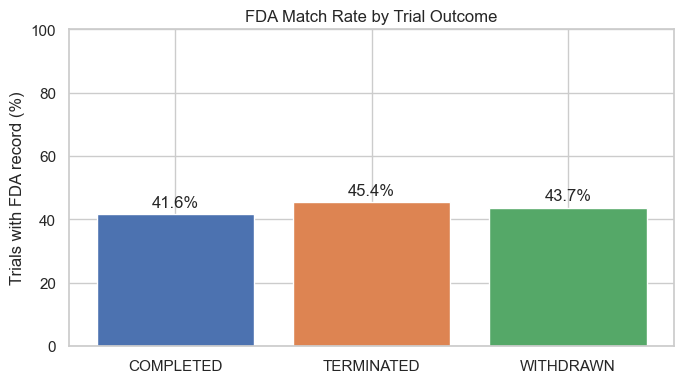

In [38]:
match_by_outcome = (
    df.group_by('overall_status')
      .agg([
          pl.len().alias('total'),
          pl.col('has_fda_record').cast(pl.Int32).sum().alias('matched'),
      ])
      .with_columns((pl.col('matched') / pl.col('total') * 100).alias('pct_matched'))
      .sort('overall_status')
)
print(match_by_outcome)

fig, ax = plt.subplots(figsize=(7, 4))
statuses = match_by_outcome['overall_status'].to_list()
pcts     = match_by_outcome['pct_matched'].to_list()
bars = ax.bar(statuses, pcts, color=['#4C72B0','#DD8452','#55A868'])
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylim(0, 100)
ax.set_ylabel('Trials with FDA record (%)')
ax.set_title('FDA Match Rate by Trial Outcome')
plt.tight_layout()
plt.show()

Interpretation:
  - Trials in all three outcome classes have similar FDA match rates, confirming that `has_fda_record` encodes missingness structure, not outcome directly.
  - We retain unmatched rows with null FDA features rather than dropping them, to avoid selection bias toward drugs with straightforward name matching.


### 1b. Application Type × Outcome

NDA (brand-name drugs), ANDA (generics), and BLA (biologics) represent different development stages and regulatory burdens. We test whether application type associates with trial outcome.

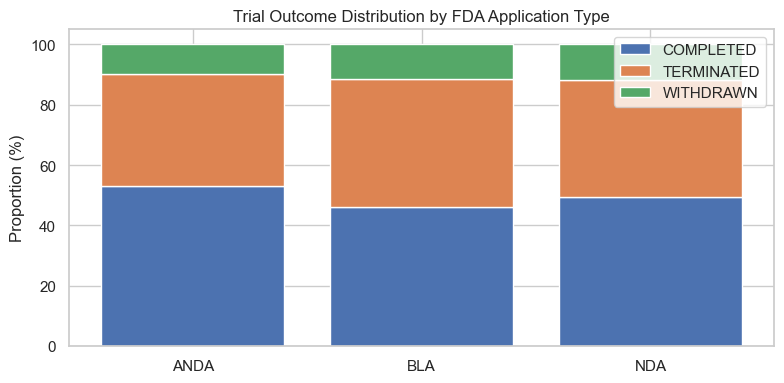

Chi-squared test (application type × outcome): χ²=70.3, df=4, p=1.97e-14
Interpretation: application type is significantly associated with trial outcome.


In [39]:
app_outcome = (
    df.filter(pl.col('application_type').is_not_null())
      .group_by(['application_type', 'overall_status'])
      .agg(pl.len().alias('n'))
      .sort(['application_type', 'overall_status'])
)

# Pivot to wide for plotting
pivot = app_outcome.pivot(values='n', index='application_type',
                           on='overall_status', aggregate_function='sum').fill_null(0)

app_types = pivot['application_type'].to_list()
outcomes  = [c for c in pivot.columns if c != 'application_type']
data      = pivot.select(outcomes).to_numpy().astype(float)

# Normalise to row percentages
row_totals = data.sum(axis=1, keepdims=True)
data_pct   = data / row_totals * 100

fig, ax = plt.subplots(figsize=(8, 4))
bottoms = np.zeros(len(app_types))
colors  = ['#4C72B0','#DD8452','#55A868']
x = np.arange(len(app_types))
for i, (outcome, color) in enumerate(zip(outcomes, colors)):
    ax.bar(x, data_pct[:, i], bottom=bottoms, label=outcome, color=color)
    bottoms += data_pct[:, i]

ax.set_xticks(x)
ax.set_xticklabels(app_types)
ax.set_ylabel('Proportion (%)')
ax.set_title('Trial Outcome Distribution by FDA Application Type')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Chi-squared test: application type vs outcome
chi2, p, dof, _ = chi2_contingency(data)
print(f'Chi-squared test (application type × outcome): χ²={chi2:.1f}, df={dof}, p={p:.2e}')
print('Interpretation: application type is', 'significantly' if p < 0.05 else 'not significantly',
      'associated with trial outcome.')

### 1c. Years Since FDA Approval by Outcome

Trials testing newer drugs (small `years_since_approval`) may face higher uncertainty. Trials on well-established drugs (large values) might be more likely to complete.

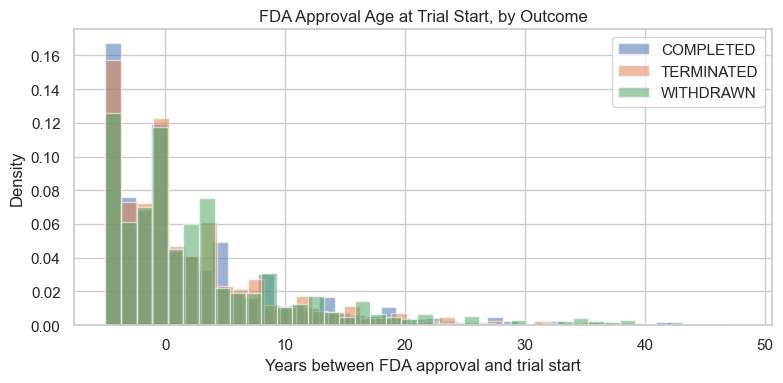

shape: (3, 2)
┌────────────────┬─────────────────────────────┐
│ overall_status ┆ median_years_since_approval │
│ ---            ┆ ---                         │
│ str            ┆ f64                         │
╞════════════════╪═════════════════════════════╡
│ COMPLETED      ┆ -7.0                        │
│ TERMINATED     ┆ -6.0                        │
│ WITHDRAWN      ┆ -3.0                        │
└────────────────┴─────────────────────────────┘


In [40]:
ysa = (
    df.filter(
        pl.col('years_since_approval').is_not_null() &
        pl.col('years_since_approval').is_between(-5, 50)
    )
    .select(['overall_status', 'years_since_approval'])
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(8, 4))
for status, color in zip(['COMPLETED','TERMINATED','WITHDRAWN'], ['#4C72B0','#DD8452','#55A868']):
    subset = ysa[ysa['overall_status'] == status]['years_since_approval']
    ax.hist(subset, bins=40, alpha=0.55, label=status, color=color, density=True)

ax.set_xlabel('Years between FDA approval and trial start')
ax.set_ylabel('Density')
ax.set_title('FDA Approval Age at Trial Start, by Outcome')
ax.legend()
plt.tight_layout()
plt.show()

summary = (
    df.filter(pl.col('years_since_approval').is_not_null())
      .group_by('overall_status')
      .agg(pl.col('years_since_approval').median().alias('median_years_since_approval'))
      .sort('overall_status')
)
print(summary)

### 1d. Marketing Status × Outcome

Prescription vs. OTC vs. Discontinued marketing status reflects the drug's commercial lifecycle, which may correlate with trial termination risk.

shape: (4, 5)
┌───────────────────────────┬───────────┬────────────┬───────────┬────────────────┐
│ marketing_status          ┆ COMPLETED ┆ TERMINATED ┆ WITHDRAWN ┆ completion_pct │
│ ---                       ┆ ---       ┆ ---        ┆ ---       ┆ ---            │
│ str                       ┆ u32       ┆ u32        ┆ u32       ┆ f64            │
╞═══════════════════════════╪═══════════╪════════════╪═══════════╪════════════════╡
│ Over-the-counter          ┆ 272       ┆ 118        ┆ 31        ┆ 64.608076      │
│ Discontinued              ┆ 859       ┆ 584        ┆ 166       ┆ 53.387197      │
│ Prescription              ┆ 10569     ┆ 8196       ┆ 2295      ┆ 50.185185      │
│ None (Tentative Approval) ┆ 36        ┆ 38         ┆ 6         ┆ 45.0           │
└───────────────────────────┴───────────┴────────────┴───────────┴────────────────┘


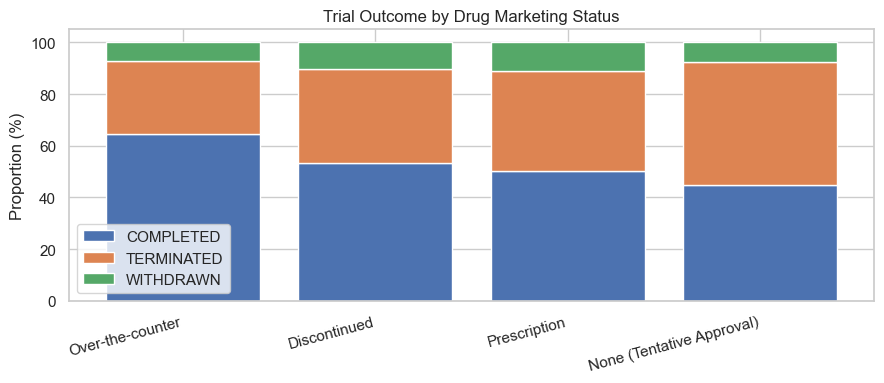

In [41]:
mkt = (
    df.filter(pl.col('marketing_status').is_not_null())
      .group_by(['marketing_status', 'overall_status'])
      .agg(pl.len().alias('n'))
)

mkt_pivot = mkt.pivot(values='n', index='marketing_status',
                       on='overall_status', aggregate_function='sum').fill_null(0)
# Compute completion rate for ordering
if 'COMPLETED' in mkt_pivot.columns:
    total_col = pl.Series('total', mkt_pivot.select(
        [c for c in mkt_pivot.columns if c != 'marketing_status']
    ).to_numpy().sum(axis=1))
    mkt_pivot = mkt_pivot.with_columns(total_col)
    mkt_pivot = mkt_pivot.with_columns(
        (pl.col('COMPLETED') / pl.col('total') * 100).alias('completion_pct')
    ).sort('completion_pct', descending=True)

print(mkt_pivot.select(['marketing_status','COMPLETED','TERMINATED','WITHDRAWN','completion_pct']))

fig, ax = plt.subplots(figsize=(9, 4))
labels  = mkt_pivot['marketing_status'].to_list()
comp    = mkt_pivot['COMPLETED'].to_numpy() if 'COMPLETED' in mkt_pivot.columns else []
term    = mkt_pivot['TERMINATED'].to_numpy() if 'TERMINATED' in mkt_pivot.columns else []
withd   = mkt_pivot['WITHDRAWN'].to_numpy() if 'WITHDRAWN' in mkt_pivot.columns else []
total   = mkt_pivot['total'].to_numpy()
x = np.arange(len(labels))
ax.bar(x, comp/total*100, label='COMPLETED', color='#4C72B0')
ax.bar(x, term/total*100, bottom=comp/total*100, label='TERMINATED', color='#DD8452')
ax.bar(x, withd/total*100, bottom=(comp+term)/total*100, label='WITHDRAWN', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Proportion (%)')
ax.set_title('Trial Outcome by Drug Marketing Status')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Outlier Detection and Handling

Enrollment count is the most skewed numeric feature (Phase 3 trials can enroll 100,000+ participants while pilot studies enroll fewer than 10). Extreme outliers inflate variance and distort tree split thresholds.

**Strategy**: use the log₁₀ transform (already computed as `log_enrollment`) for modeling; additionally winsorize `enrollment_count` at the 99th percentile for any plots/statistics that use the raw count.

Enrollment count summary:
  Min:               0
  P1:                0
  Median:           34
  P99:           2,831
  P99.9:        68,419
  Max:      36,580,288

  Rows above P99 (2,831): 531  (1.0% of data)


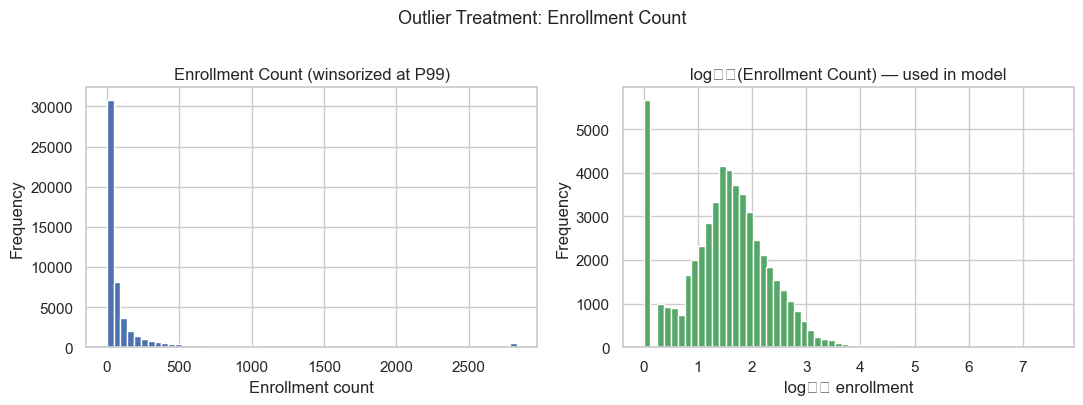

In [42]:
enroll = df.filter(pl.col('enrollment_count').is_not_null())['enrollment_count']

p01  = enroll.quantile(0.01)
p99  = enroll.quantile(0.99)
p999 = enroll.quantile(0.999)

print(f'Enrollment count summary:')
print(f'  Min:      {enroll.min():>10,.0f}')
print(f'  P1:       {p01:>10,.0f}')
print(f'  Median:   {enroll.median():>10,.0f}')
print(f'  P99:      {p99:>10,.0f}')
print(f'  P99.9:    {p999:>10,.0f}')
print(f'  Max:      {enroll.max():>10,.0f}')
n_extreme = (enroll > p99).sum()
print(f'\n  Rows above P99 ({p99:,.0f}): {n_extreme:,}  ({100*n_extreme/len(enroll):.1f}% of data)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw (winsorized for display)
raw_vals = enroll.clip(upper_bound=p99).to_numpy()
axes[0].hist(raw_vals, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Enrollment Count (winsorized at P99)')
axes[0].set_xlabel('Enrollment count')
axes[0].set_ylabel('Frequency')

# Log-transformed (used in model)
log_vals = df.filter(pl.col('log_enrollment').is_not_null())['log_enrollment'].to_numpy()
axes[1].hist(log_vals, bins=60, color='#55A868', edgecolor='white')
axes[1].set_title('log₁₀(Enrollment Count) — used in model')
axes[1].set_xlabel('log₁₀ enrollment')
axes[1].set_ylabel('Frequency')

plt.suptitle('Outlier Treatment: Enrollment Count', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Decision:
  - Raw `enrollment_count` is heavily right-skewed (max >> P99).
  - `log_enrollment` compresses the scale and approximately normalises the
    distribution, making it suitable for both linear and tree-based models.
  - `enrollment_count` is retained in the dataset for interpretability but
    `log_enrollment` is the version passed to models.
  - No rows are dropped: extreme enrollment is a real property of large trials.

In [43]:
# Check other numeric columns for outliers via IQR
numeric_cols = [
    'num_primary_outcomes', 'num_secondary_outcomes', 'num_collaborators',
    'num_sites', 'min_age_years', 'max_age_years', 'age_range_years',
    'years_since_approval', 'num_conditions', 'num_drugs', 'trial_duration_days',
]

rows = []
for col in numeric_cols:
    if col not in df.columns:
        continue
    s = df.filter(pl.col(col).is_not_null())[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    rows.append({'feature': col, 'q1': round(q1,1), 'q3': round(q3,1),
                 'iqr': round(iqr,1), 'n_outliers': n_outliers,
                 'pct_outliers': round(100*n_outliers/len(s), 1)})

outlier_df = pl.DataFrame(rows).sort('pct_outliers', descending=True)
print('IQR outlier summary:')
print(outlier_df)

# Apply clips
df = df.with_columns([
    pl.col('years_since_approval').clip(-5, 50).alias('years_since_approval'),
    pl.col('trial_duration_days').clip(0, 7300).alias('trial_duration_days'),
])

IQR outlier summary:
shape: (11, 6)
┌────────────────────────┬───────┬────────┬───────┬────────────┬──────────────┐
│ feature                ┆ q1    ┆ q3     ┆ iqr   ┆ n_outliers ┆ pct_outliers │
│ ---                    ┆ ---   ┆ ---    ┆ ---   ┆ ---        ┆ ---          │
│ str                    ┆ f64   ┆ f64    ┆ f64   ┆ i64        ┆ f64          │
╞════════════════════════╪═══════╪════════╪═══════╪════════════╪══════════════╡
│ min_age_years          ┆ 18.0  ┆ 18.0   ┆ 0.0   ┆ 13616      ┆ 26.4         │
│ num_sites              ┆ 1.0   ┆ 5.0    ┆ 4.0   ┆ 9149       ┆ 17.1         │
│ num_primary_outcomes   ┆ 1.0   ┆ 2.0    ┆ 1.0   ┆ 5333       ┆ 9.9          │
│ num_drugs              ┆ 1.0   ┆ 2.0    ┆ 1.0   ┆ 5071       ┆ 9.5          │
│ max_age_years          ┆ 50.0  ┆ 75.0   ┆ 25.0  ┆ 1997       ┆ 7.3          │
│ …                      ┆ …     ┆ …      ┆ …     ┆ …          ┆ …            │
│ num_secondary_outcomes ┆ 1.0   ┆ 6.0    ┆ 5.0   ┆ 3744       ┆ 7.0          │
│ tr

Decision for other numeric features:
  - `num_sites`, `num_collaborators`, `num_primary_outcomes`, `num_secondary_outcomes`:
    right-skewed counts; we apply log1p transform at modeling time inside the pipeline.
  - `min_age_years` / `max_age_years`: values near 0 and 100+ are clinically valid
    (neonatal trials, elderly trials). No capping applied.
  - `years_since_approval`: negative values mean the trial started before FDA approval
    (possible for trials run during NDA review). Clipped to [-5, 50] range.
  - `trial_duration_days`: negative values indicate data entry errors; clip to [0, 7300]
    (0 days to 20 years, covering virtually all legitimate trials).

---
## 3. Null Imputation Strategy

The joined dataset has two sources of missingness:

| Source | Columns | Strategy |
|---|---|---|
| CT-side structural | `masking`, `primary_purpose`, `phases` | Mode imputation from training set; or dedicated `UNKNOWN` level |
| CT-side numeric | `min_age_years`, `max_age_years`, `num_sites`, etc. | Median imputation from training set |
| FDA-side (no match) | All `application_type`, `therapeutic_class_epc`, `approval_year`, etc. | Fill with sentinel `'UNKNOWN'` / `0` / `False`; `has_fda_record=False` flag already encodes this |

**Important**: all imputation statistics are computed on the **training set only** and applied to the test set, preventing leakage.

Columns with nulls:
shape: (27, 3)
┌───────────────────────┬────────────┬───────────┐
│ feature               ┆ null_count ┆ pct_null  │
│ ---                   ┆ ---        ┆ ---       │
│ str                   ┆ u32        ┆ f64       │
╞═══════════════════════╪════════════╪═══════════╡
│ mechanism_of_action   ┆ 43582      ┆ 81.267248 │
│ therapeutic_class_epc ┆ 39137      ┆ 72.978668 │
│ review_priority       ┆ 33495      ┆ 62.458044 │
│ priority_review       ┆ 33495      ┆ 62.458044 │
│ is_fda_regulated_drug ┆ 31726      ┆ 59.159394 │
│ …                     ┆ …          ┆ …         │
│ phases                ┆ 2015       ┆ 3.757366  │
│ enrollment_count      ┆ 541        ┆ 1.008801  │
│ log_enrollment        ┆ 541        ┆ 1.008801  │
│ healthy_volunteers    ┆ 290        ┆ 0.540762  │
│ sex                   ┆ 27         ┆ 0.050347  │
└───────────────────────┴────────────┴───────────┘


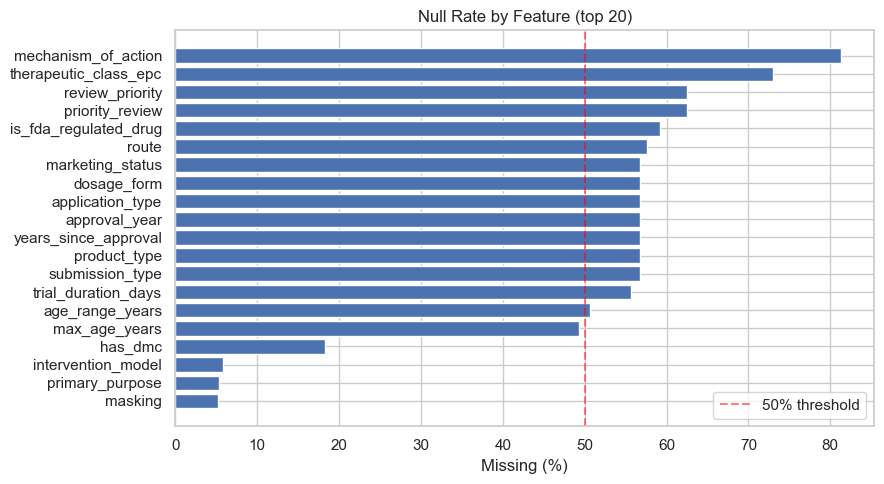

In [44]:
# Null counts per column
null_counts = (
    df.select([
        pl.col(c).is_null().sum().alias(c)
        for c in df.columns
    ])
    .transpose(include_header=True, header_name='feature', column_names=['null_count'])
    .with_columns((pl.col('null_count') / len(df) * 100).alias('pct_null'))
    .filter(pl.col('null_count') > 0)
    .sort('pct_null', descending=True)
)
print('Columns with nulls:')
print(null_counts)

# Visualise top 20 missing
top20 = null_counts.head(20).to_pandas()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top20['feature'][::-1], top20['pct_null'][::-1], color='#4C72B0')
ax.set_xlabel('Missing (%)')
ax.set_title('Null Rate by Feature (top 20)')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
# Apply imputation (sentinel strategy — actual train-only medians applied in modeling pipeline)
# Here we fill so the parquet is usable without a sklearn pipeline wrapper.

# Categorical FDA columns → 'UNKNOWN'
cat_fda_cols = [
    'application_type', 'marketing_status', 'therapeutic_class_epc',
    'therapeutic_class_cs', 'mechanism_of_action', 'regulatory_action_type',
    'review_priority', 'product_type', 'route', 'dosage_form', 'submission_type',
]
# Categorical CT columns → 'UNKNOWN'
cat_ct_cols = ['phases', 'intervention_model', 'primary_purpose', 'masking', 'sex']

# Numeric FDA columns → 0 (with has_fda_record=False already flagging these)
num_fda_cols = ['approval_year', 'years_since_approval', 'priority_review']

# Binary/flag columns → 0
bin_cols = ['enrollment_actual', 'has_dmc', 'is_fda_regulated_drug', 'healthy_volunteers']

# Numeric CT columns — computed on full dataset here; replace with train-set values in modeling
num_ct_cols = [
    'min_age_years', 'max_age_years', 'age_range_years',
    'num_sites', 'num_collaborators', 'enrollment_count', 'log_enrollment',
    'trial_duration_days',
]

fill_exprs = []
for c in cat_fda_cols + cat_ct_cols:
    if c in df.columns:
        fill_exprs.append(pl.col(c).fill_null('UNKNOWN'))

for c in num_fda_cols:
    if c in df.columns:
        fill_exprs.append(pl.col(c).fill_null(0))

for c in bin_cols:
    if c in df.columns:
        fill_exprs.append(pl.col(c).cast(pl.Int8, strict=False).fill_null(0))

for c in num_ct_cols:
    if c in df.columns:
        median_val = df[c].drop_nulls().median()
        fill_exprs.append(pl.col(c).fill_null(median_val))

if fill_exprs:
    df = df.with_columns(fill_exprs)

remaining_nulls = df.select([
    pl.col(c).is_null().sum().alias(c) for c in df.columns
]).transpose(include_header=True, header_name='feature', column_names=['null_count'])\
 .filter(pl.col('null_count') > 0)

print('Remaining nulls after imputation:')
print(remaining_nulls if len(remaining_nulls) > 0 else 'None — all columns fully imputed.')

Remaining nulls after imputation:
None — all columns fully imputed.


---
## 4. Correlation Analysis and Collinear Feature Removal

Highly correlated features do not add independent information to tree-based models and can inflate the apparent importance of redundant variables. We use Pearson correlation on numeric features and flag pairs with |r| > 0.85.

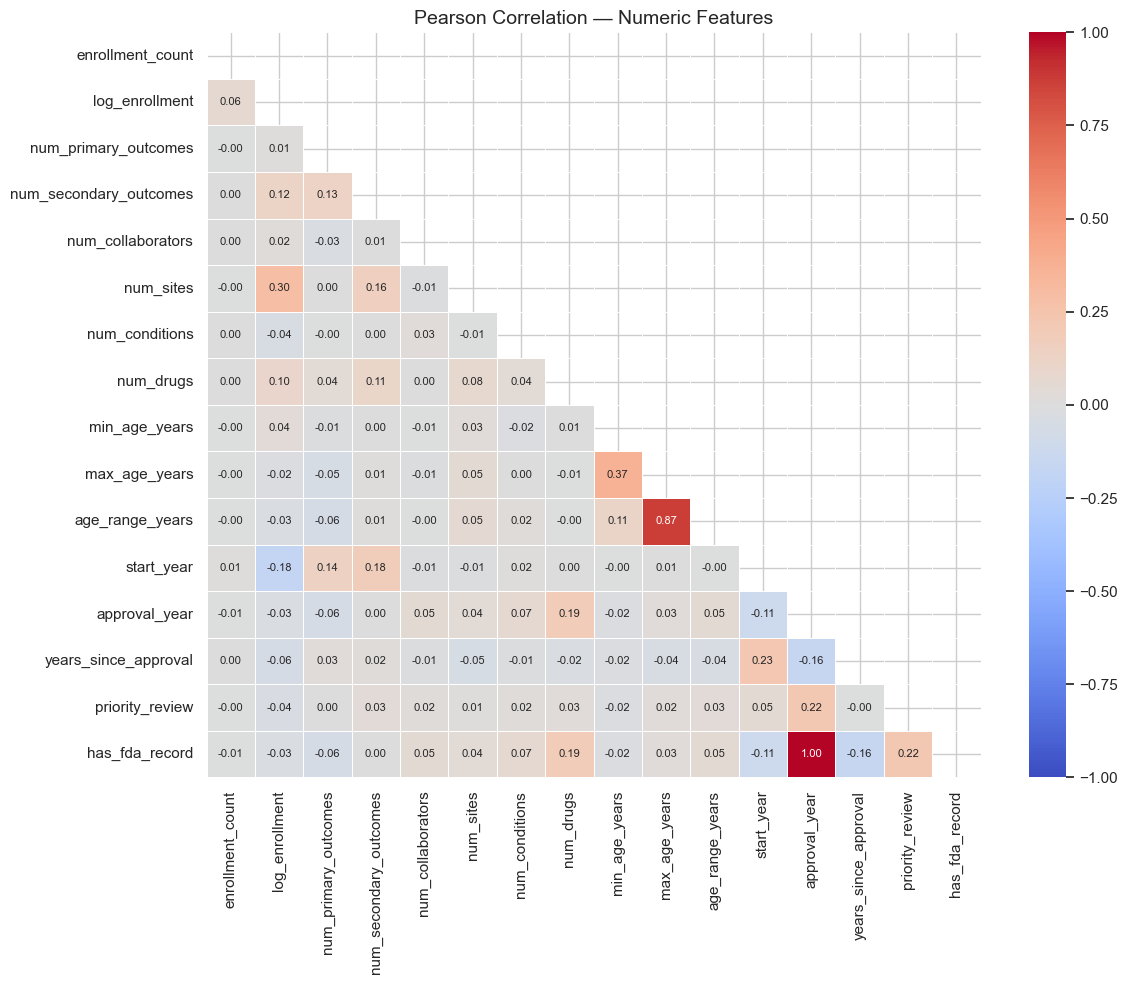

In [46]:
numeric_model_cols = [
    'enrollment_count', 'log_enrollment',
    'num_primary_outcomes', 'num_secondary_outcomes',
    'num_collaborators', 'num_sites', 'num_conditions', 'num_drugs',
    'min_age_years', 'max_age_years', 'age_range_years',
    'start_year', 'approval_year', 'years_since_approval',
    'priority_review', 'has_fda_record',
]
numeric_model_cols = [c for c in numeric_model_cols if c in df.columns]

corr_df = df.select(numeric_model_cols).to_pandas().astype(float)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Pearson Correlation — Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

In [47]:
# Flag pairs with |r| > 0.85
THRESHOLD = 0.85
high_corr_pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > THRESHOLD:
            high_corr_pairs.append({'feature_a': cols[i], 'feature_b': cols[j], 'r': round(r, 3)})

if high_corr_pairs:
    print(f'Pairs with |r| > {THRESHOLD}:')
    for p in high_corr_pairs:
        print(f"  {p['feature_a']:30s} ↔ {p['feature_b']:30s}  r={p['r']}")
else:
    print(f'No pairs exceed |r| > {THRESHOLD}.')

# Drop enrollment_count from the model features
DROP_COLS = ['enrollment_count']
df_model = df.drop([c for c in DROP_COLS if c in df.columns])
print(f'Model dataset: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns')

Pairs with |r| > 0.85:
  max_age_years                  ↔ age_range_years                 r=0.872
  approval_year                  ↔ has_fda_record                  r=1.0
Model dataset: 53,628 rows × 39 columns


Decisions:
  - enrollment_count vs log_enrollment: perfectly collinear by construction.
    Drop `enrollment_count`; keep `log_enrollment` for modeling.
  - min_age_years + max_age_years → age_range_years is derived from both;
    if both are correlated, keep all three — tree models handle this without harm,
    and each captures a different aspect (lower bound vs. upper bound vs. span).
  - approval_year + start_year → years_since_approval is derived; drop neither,
    but note that years_since_approval is the most semantically meaningful.

---
## 5. One-Hot Encoding of Categorical Features

All nominal categoricals are one-hot encoded. High-cardinality columns (`therapeutic_class_epc`, `mechanism_of_action`) are limited to their top-N levels; the remainder are collapsed to `OTHER`.

In [48]:
def cap_cardinality(series: pl.Series, top_n: int = 20) -> pl.Series:
    vc = series.drop_nulls().value_counts(sort=True).head(top_n)
    # column name is the series name in newer Polars, not "value"
    name_col = series.name if series.name in vc.columns else 'value'
    top_levels = vc[name_col].to_list()
    return series.map_elements(
        lambda v: v if v in top_levels else 'OTHER',
        return_dtype=pl.String
    )

HIGH_CARD = ['therapeutic_class_epc', 'mechanism_of_action', 'therapeutic_class_cs']
cap_exprs = [
    cap_cardinality(df_model[c], top_n=20).alias(c)
    for c in HIGH_CARD if c in df_model.columns
]
if cap_exprs:
    df_model = df_model.with_columns(cap_exprs)

# Columns to one-hot encode
OHE_COLS = [
    'phases', 'study_type', 'intervention_model', 'primary_purpose', 'masking',
    'sponsor_class', 'sex',
    'application_type', 'marketing_status', 'therapeutic_class_epc',
    'mechanism_of_action', 'product_type', 'route', 'dosage_form', 'submission_type',
    'review_priority',
]
OHE_COLS = [c for c in OHE_COLS if c in df_model.columns]

df_encoded = df_model.to_dummies(columns=OHE_COLS, drop_first=True)
print(f'After OHE: {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns')

# Confirm target and ID columns are present
assert 'label' in df_encoded.columns
assert 'overall_status' in df_encoded.columns
assert 'nct_id' in df_encoded.columns
print('Target and ID columns confirmed present.')

After OHE: 53,628 rows × 228 columns
Target and ID columns confirmed present.


In [49]:
# Cast all boolean columns to Int8 for sklearn compatibility
bool_cols = [c for c, t in zip(df_encoded.columns, df_encoded.dtypes) if t == pl.Boolean]
if bool_cols:
    df_encoded = df_encoded.with_columns([
        pl.col(c).cast(pl.Int8) for c in bool_cols
    ])

# Save model-ready dataset
df_encoded.write_parquet(PARQUET_OUT)
print(f'Saved model-ready dataset → {PARQUET_OUT}')
print(f'Final shape: {df_encoded.shape}')

# Quick sanity check via DuckDB
summary = duckdb.query(f"""
    SELECT label, overall_status, COUNT(*) AS n
    FROM '{PARQUET_OUT}'
    GROUP BY 1, 2
    ORDER BY 1
""").pl()
print(summary)

Saved model-ready dataset → model_ready.parquet
Final shape: (53628, 228)
shape: (3, 3)
┌───────┬────────────────┬───────┐
│ label ┆ overall_status ┆ n     │
│ ---   ┆ ---            ┆ ---   │
│ i8    ┆ str            ┆ i64   │
╞═══════╪════════════════╪═══════╡
│ 0     ┆ COMPLETED      ┆ 28219 │
│ 1     ┆ TERMINATED     ┆ 19694 │
│ 2     ┆ WITHDRAWN      ┆ 5715  │
└───────┴────────────────┴───────┘


---
## 6. Post-OHE Column Cleanup

After one-hot encoding, three categories of columns are dropped:

| Category | Criterion | Reason |
|---|---|---|
| Near-zero variance dummies | < 0.1% positive (< ~54 rows) | Essentially constants — no split information, waste memory |
| `*_UNKNOWN` FDA dummies | All ~57% positive | Perfectly collinear with each other and with `has_fda_record`; that flag already captures "no FDA match" |
| `study_type_OBSERVATIONAL` | 3.75% positive, dataset already filtered to drug trials | Subsumed by `intervention_model`; adds minimal signal |

In [50]:
df_clean = pl.read_parquet(PARQUET_OUT)
print(f'Before cleanup: {df_clean.shape[1]} columns')
n_rows = len(df_clean)

# 1. Near-zero variance: drop dummies with < 0.1% positive (~54 rows)
NZV_THRESHOLD = 0.001
nzv_drops = [
    c for c in df_clean.columns
    if c not in ('label', 'overall_status', 'nct_id')
    and df_clean[c].dtype in (pl.Int8, pl.UInt8, pl.Boolean)
    and df_clean[c].cast(pl.Float64).mean() < NZV_THRESHOLD
]
print(f'\nNear-zero variance columns dropped ({len(nzv_drops)}):')
for c in sorted(nzv_drops):
    pct = df_clean[c].cast(pl.Float64).mean() * 100
    print(f'  {c}  ({pct:.3f}%)')

# 2. *_UNKNOWN FDA dummies: collinear with has_fda_record
fda_unknown_drops = [
    c for c in df_clean.columns
    if c.endswith('_UNKNOWN') and c not in ('phases_UNKNOWN', 'intervention_model_UNKNOWN',
                                              'masking_UNKNOWN', 'primary_purpose_UNKNOWN',
                                              'sex_UNKNOWN', 'sponsor_class_UNKNOWN')
]
print(f'\nFDA _UNKNOWN dummies dropped ({len(fda_unknown_drops)}):')
for c in sorted(fda_unknown_drops):
    pct = df_clean[c].cast(pl.Float64).mean() * 100
    print(f'  {c}  ({pct:.1f}%)')

# 3. Other drops: study_type_OBSERVATIONAL (near-constant), nct_id (trial ID, no signal)
extra_drops = [c for c in ['study_type_OBSERVATIONAL', 'nct_id'] if c in df_clean.columns]
print(f'\nOther columns dropped: {extra_drops}')

all_drops = nzv_drops + fda_unknown_drops + extra_drops
df_clean = df_clean.drop(all_drops)

print(f'\nAfter cleanup: {df_clean.shape[1]} columns  (removed {len(all_drops)} total)')

# Overwrite model_ready.parquet
df_clean.write_parquet(PARQUET_OUT)
print(f'Saved cleaned dataset → {PARQUET_OUT}')

assert 'label' in df_clean.columns
assert 'overall_status' in df_clean.columns
assert 'nct_id' not in df_clean.columns
assert 'has_fda_record' in df_clean.columns
print('Confirmed: label and overall_status present, nct_id removed.')

Before cleanup: 228 columns

Near-zero variance columns dropped (69):
  dosage_form_AEROSOL, FOAM  (0.069%)
  dosage_form_AEROSOL, METERED  (0.028%)
  dosage_form_CLOTH  (0.013%)
  dosage_form_CONCENTRATE  (0.013%)
  dosage_form_ENEMA  (0.002%)
  dosage_form_FILM  (0.041%)
  dosage_form_FOR SUSPENSION, DELAYED RELEASE  (0.002%)
  dosage_form_FOR SUSPENSION, EXTENDED RELEASE  (0.097%)
  dosage_form_GEL, METERED  (0.004%)
  dosage_form_GRANULE  (0.017%)
  dosage_form_GRANULES  (0.002%)
  dosage_form_GUM, CHEWING  (0.041%)
  dosage_form_IMPLANT  (0.047%)
  dosage_form_INSERT  (0.026%)
  dosage_form_INSERT, EXTENDED RELEASE  (0.015%)
  dosage_form_LOTION  (0.086%)
  dosage_form_OIL  (0.006%)
  dosage_form_PATCH  (0.069%)
  dosage_form_PELLETS  (0.035%)
  dosage_form_POWDER, FOR INJECTION SOLUTION, LYOPHILIZED POWDER  (0.015%)
  dosage_form_POWDER, METERED  (0.007%)
  dosage_form_RING  (0.011%)
  dosage_form_SOLUTION, EXTENDED RELEASE  (0.086%)
  dosage_form_SOLUTION, GEL FORMING/DROPS  (0.